In [9]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("../data/time_series_country.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         3056 non-null   str    
 1   Subregion       3056 non-null   str    
 2   Year            3056 non-null   int64  
 3   Country Code    3056 non-null   str    
 4   Total_Deaths    3056 non-null   float64
 5   Region          3056 non-null   str    
 6   Population      3056 non-null   float64
 7   Mortality_Rate  3056 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 191.1 KB


# 4.1 Global Analysis

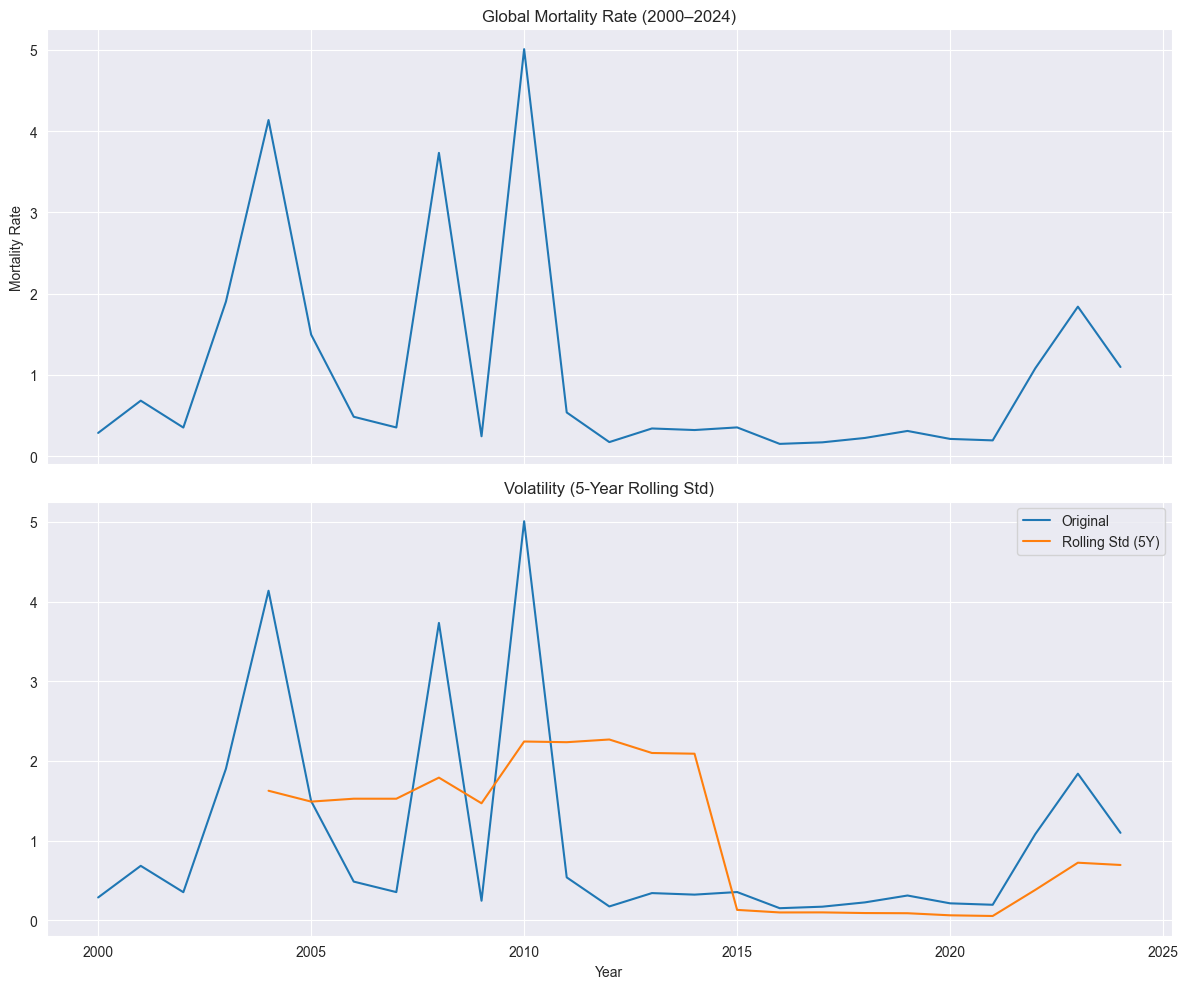

In [32]:
# 4.1 Global Series
global_ts = (
    df.groupby("Year")[["Total_Deaths", "Population"]]
      .sum()
      .sort_index()
)

# tính lại Mortality Rate theo công thức chuẩn
global_ts["Mortality_Rate"] = (global_ts["Total_Deaths"] / global_ts["Population"]) * 100000

# lấy riêng chuỗi Mortality_Rate để phân tích time series
ts = global_ts["Mortality_Rate"].astype(float)

# Rolling Statistics
rolling_std = ts.rolling(window=5).std()

# Figure 1: Trend + Volatility
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(ts.index, ts.values)
axes[0].set_title("Global Mortality Rate (2000–2024)")
axes[0].set_ylabel("Mortality Rate")

axes[1].plot(ts.index, ts.values, label="Original")
axes[1].plot(ts.index, rolling_std.values, label="Rolling Std (5Y)")
axes[1].legend()
axes[1].set_title("Volatility (5-Year Rolling Std)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

# 4.2 REGIONAL ANALYSIS

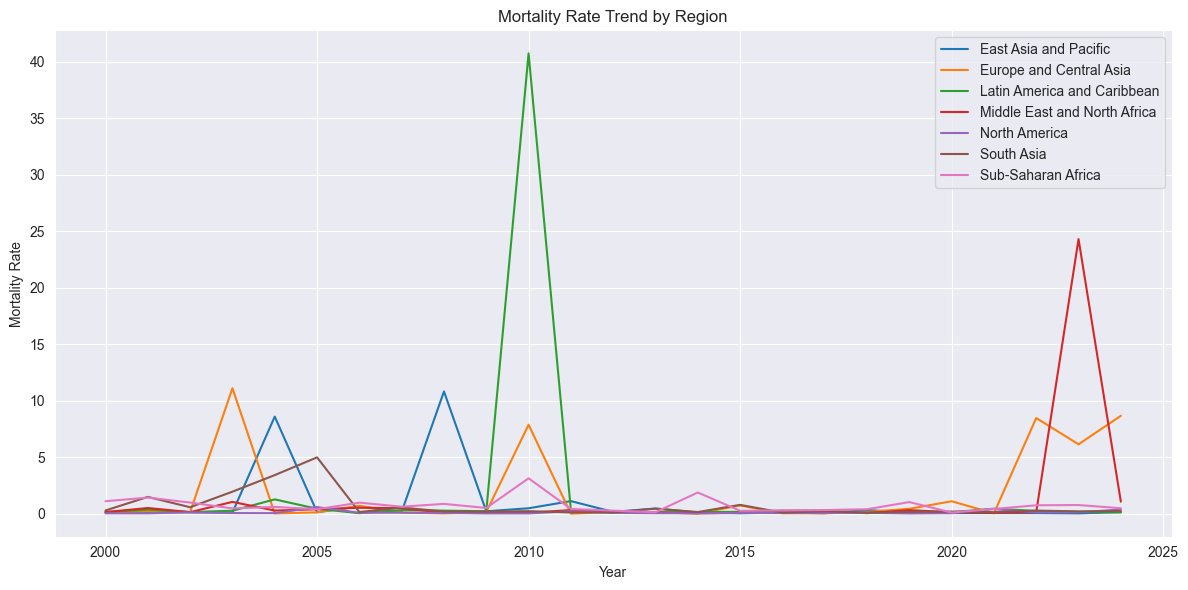

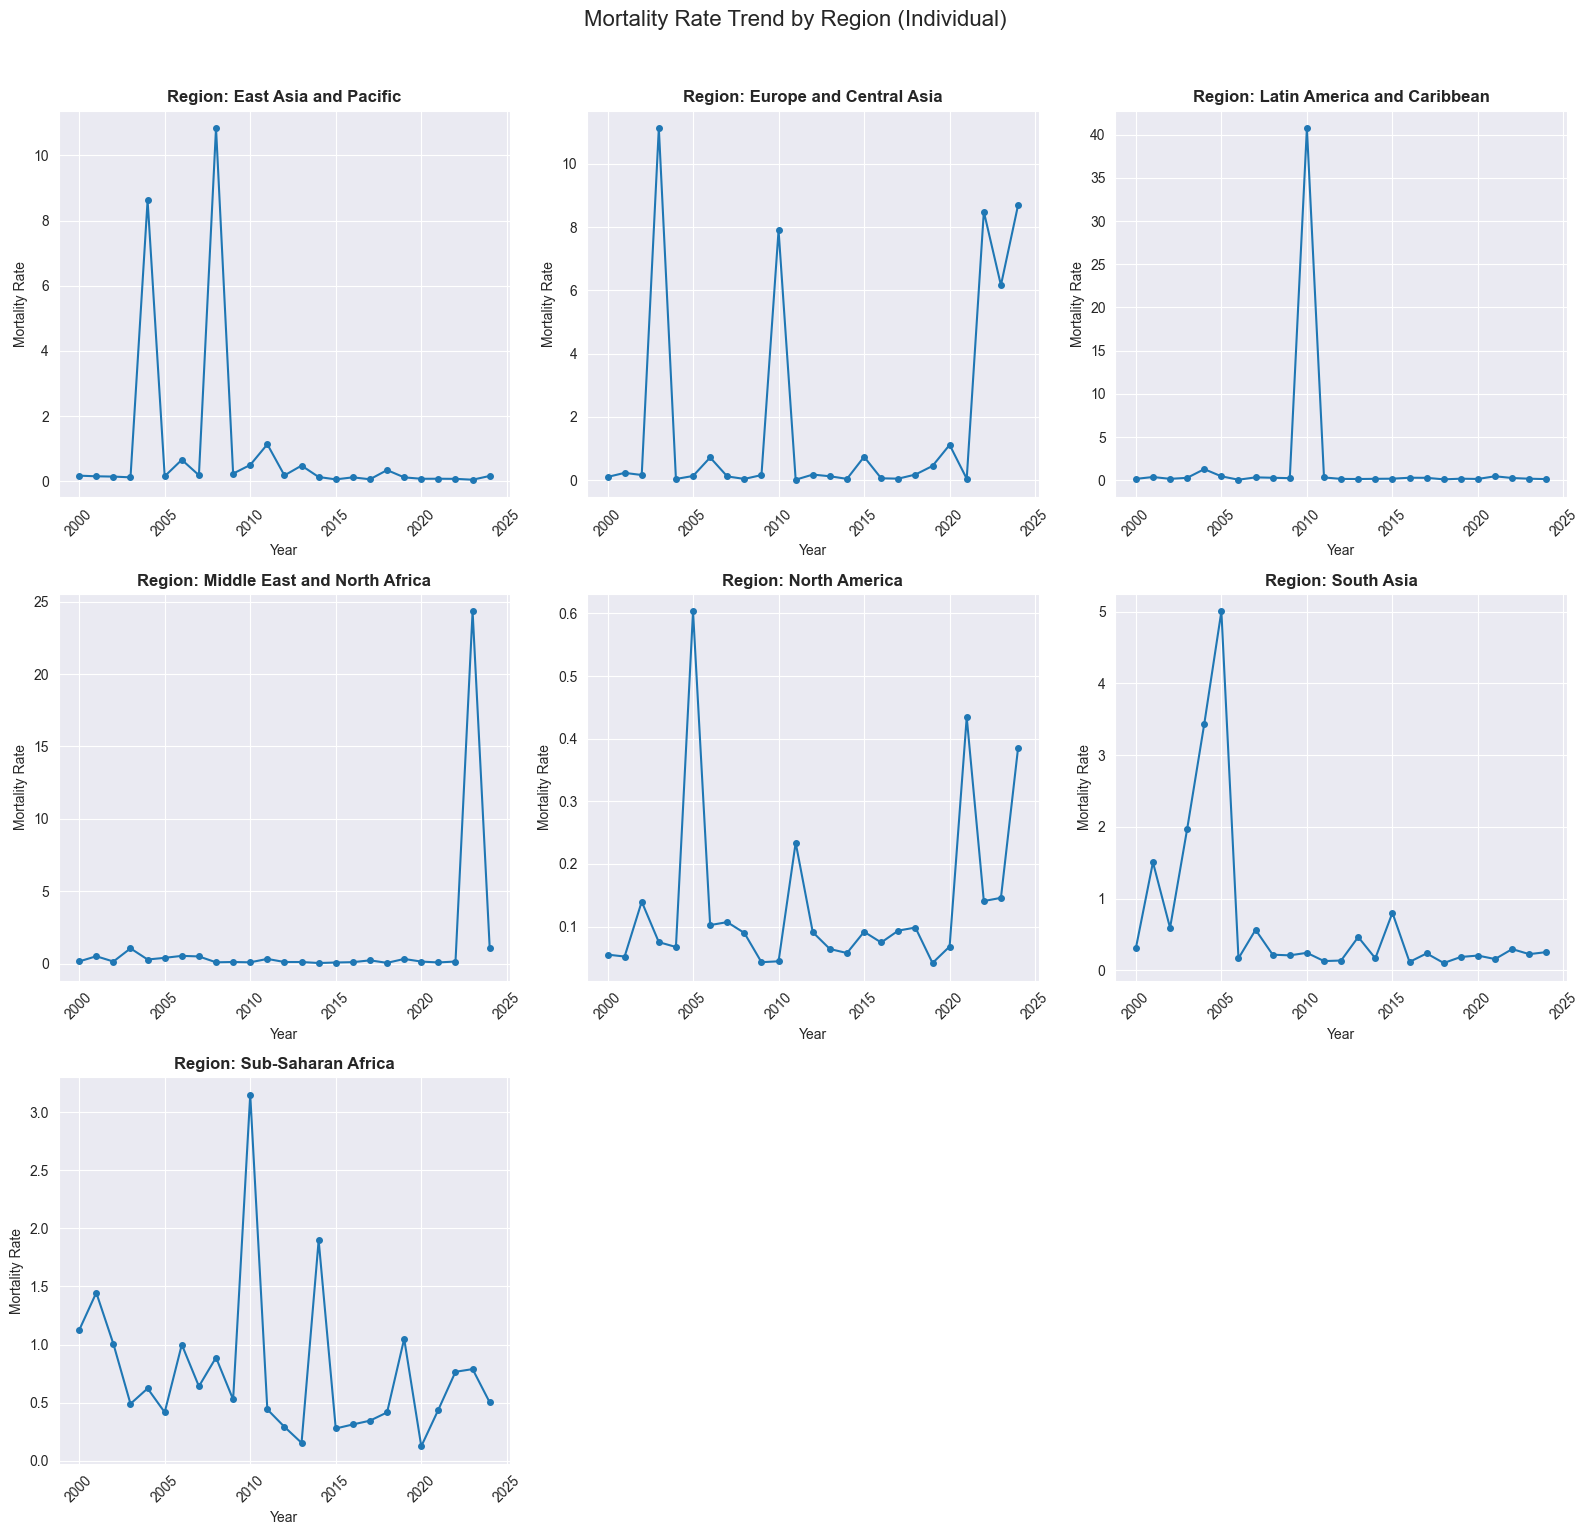

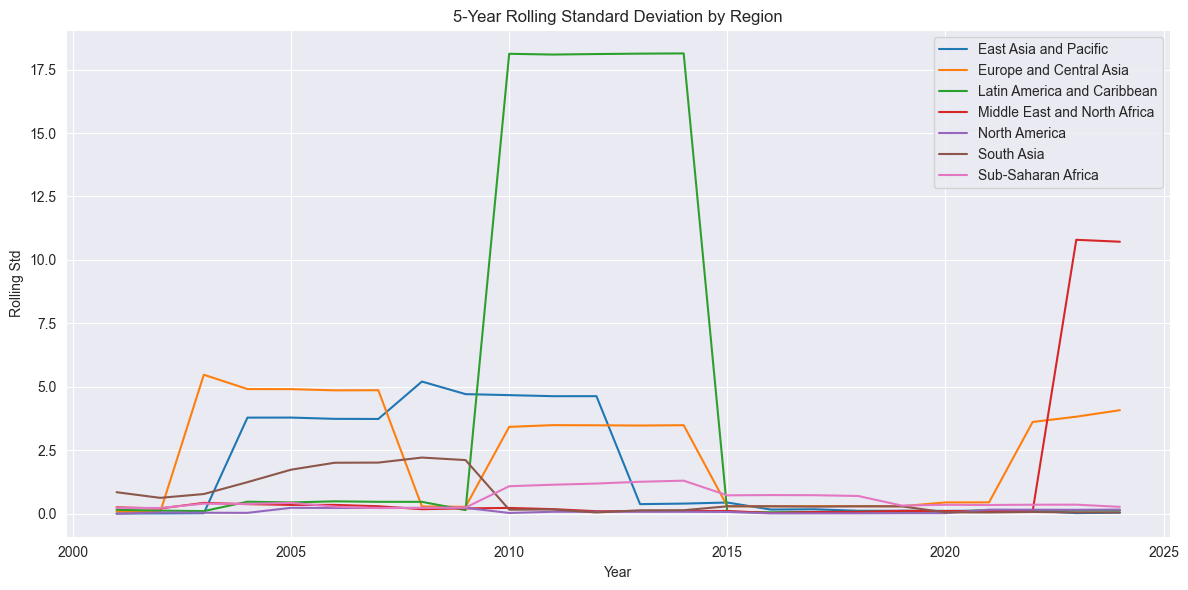

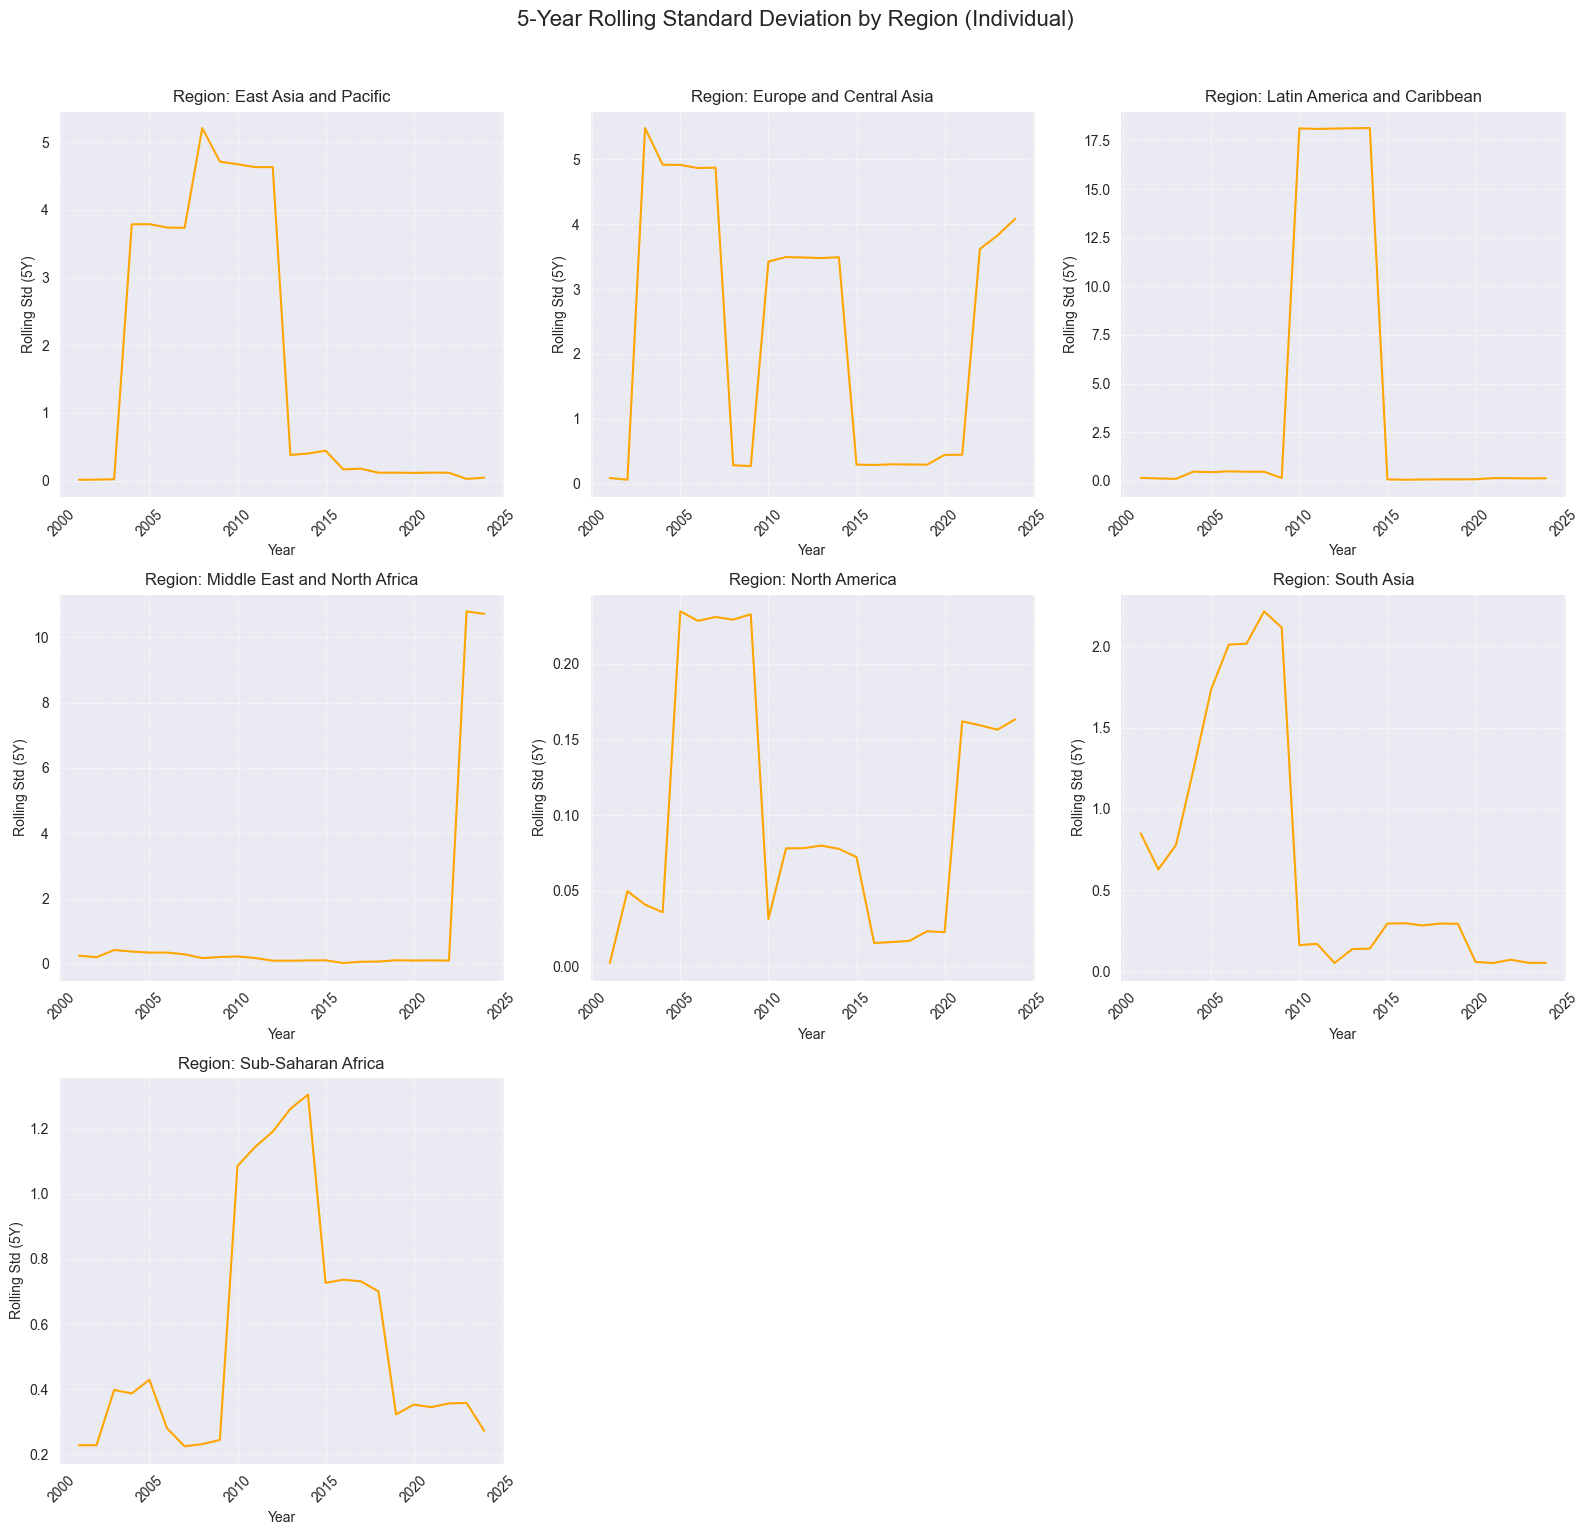

In [35]:
# 4.2 Region Series
ts = (
    df.groupby(["Year", "Region"])[["Total_Deaths", "Population"]]
      .sum()
      .sort_index()
)

# tính lại Mortality Rate
ts["Mortality_Rate"] = (ts["Total_Deaths"] / ts["Population"]) * 100000

regions = ts.index.get_level_values("Region").unique()

window = 5

# ===== Figure 1: Trend Comparison =====
plt.figure(figsize=(12,6))

for region in regions:
    region_ts = ts.xs(region, level="Region")["Mortality_Rate"].astype(float)
    plt.plot(region_ts.index, region_ts.values, label=region)

plt.title("Mortality Rate Trend by Region")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend()
plt.tight_layout()
plt.show()

# ===== Figure 1b: Trend by Region (Subplots) =====

import numpy as np
import matplotlib.pyplot as plt

n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows), # Tăng nhẹ chiều cao để không bị đè nhãn
    sharex=False             # Chỉnh thành False để hiện label cho từng hình
)

axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    # Lấy dữ liệu cho từng vùng
    region_ts = ts.xs(region, level="Region")["Mortality_Rate"].astype(float)

    ax = axes[i]
    ax.plot(region_ts.index, region_ts.values, marker='o', markersize=4) # Thêm marker cho rõ nét
    ax.set_title(f"Region: {region}", fontsize=12, fontweight='bold')

    # Hiện label cho từng subplot
    ax.set_xlabel("Year")
    ax.set_ylabel("Mortality Rate")

    # Xoay nhãn 45 độ để không bị dính vào nhau
    ax.tick_params(axis="x", rotation=45, labelbottom=True)

# Tắt các subplot dư thừa nếu số lượng region không lấp đầy grid
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Mortality Rate Trend by Region (Individual)", fontsize=16, y=1.02)

# Sử dụng tight_layout để tự động căn chỉnh khoảng cách giữa các hình
plt.tight_layout()
plt.show()
# ===== Figure 2: Rolling Volatility =====
plt.figure(figsize=(12,6))

for region in regions:
    region_ts = ts.xs(region, level="Region")["Mortality_Rate"].astype(float)
    rolling_std = region_ts.rolling(window=window, min_periods=1).std()
    plt.plot(rolling_std.index, rolling_std.values, label=region)

plt.title(f"{window}-Year Rolling Standard Deviation by Region")
plt.xlabel("Year")
plt.ylabel("Rolling Std")
plt.legend()
plt.tight_layout()
plt.show()
# ===== Figure 2b: Rolling Std by Region (Subplots) =====

import numpy as np
import matplotlib.pyplot as plt

n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows), # Tăng chiều cao để đủ chỗ cho x-label mỗi hàng
    sharex=False             # Tắt sharex để hiện label dưới mỗi hình
)

axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    region_ts = ts.xs(region, level="Region")["Mortality_Rate"].astype(float)
    rolling_std = region_ts.rolling(window=window, min_periods=1).std()

    ax = axes[i]
    # Vẽ đường Rolling Std với màu sắc nổi bật (ví dụ: màu cam)
    ax.plot(rolling_std.index, rolling_std.values, color='orange', label='Rolling Std')

    ax.set_title(f"Region: {region}", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rolling Std ({window}Y)")

    # Đảm bảo hiển thị ticks và xoay 45 độ cho mọi subplot
    ax.tick_params(axis="x", rotation=45, labelbottom=True)
    ax.grid(True, linestyle='--', alpha=0.6) # Thêm grid cho dễ quan sát biến động

# Tắt subplot dư
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"{window}-Year Rolling Standard Deviation by Region (Individual)",
             fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

# 4.3 SELECTED COUNTRY-LEVEL ANALYSIS

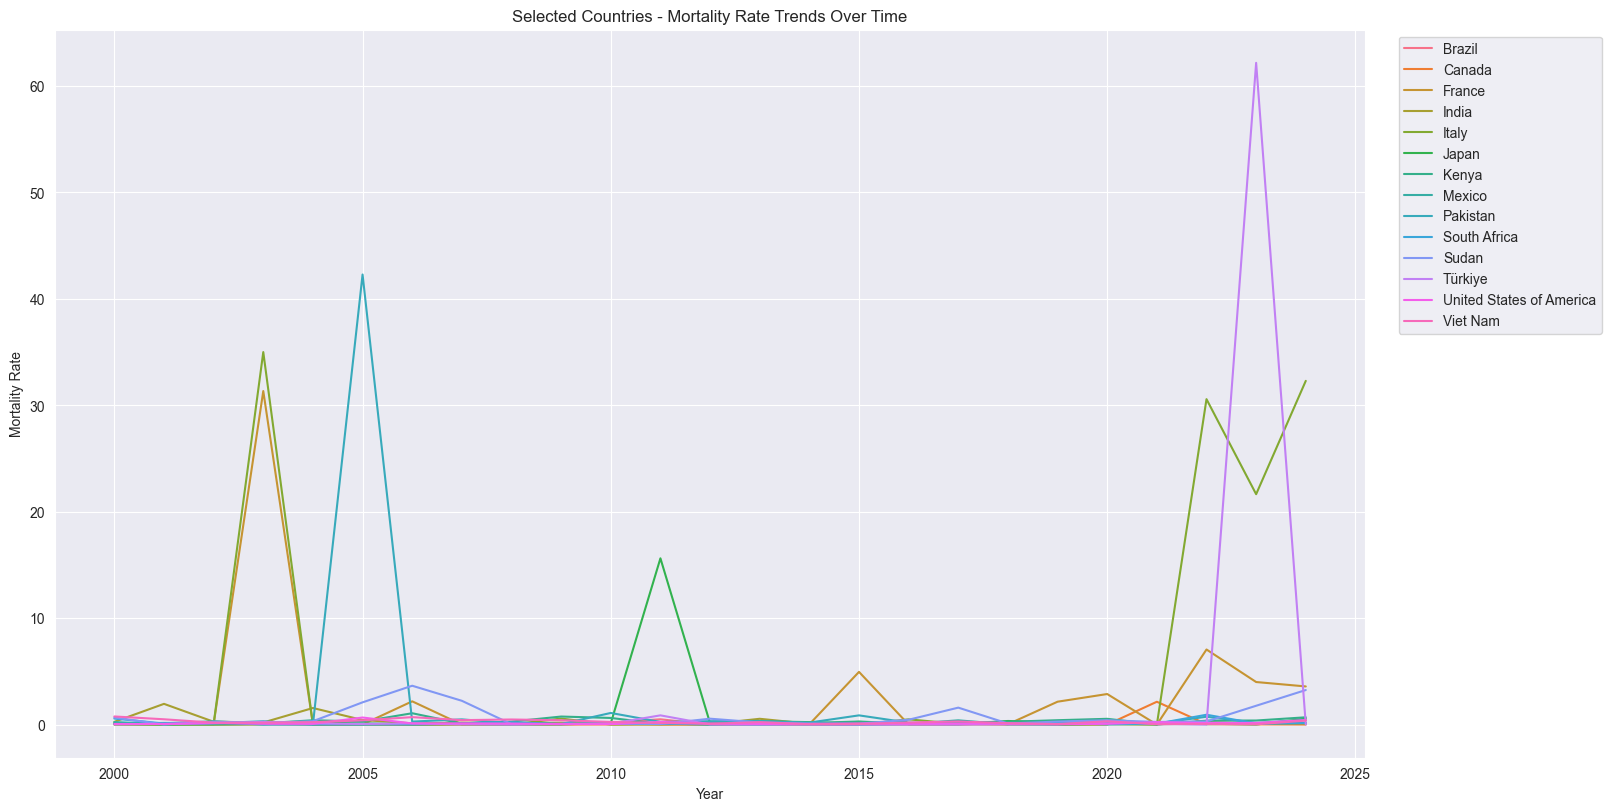

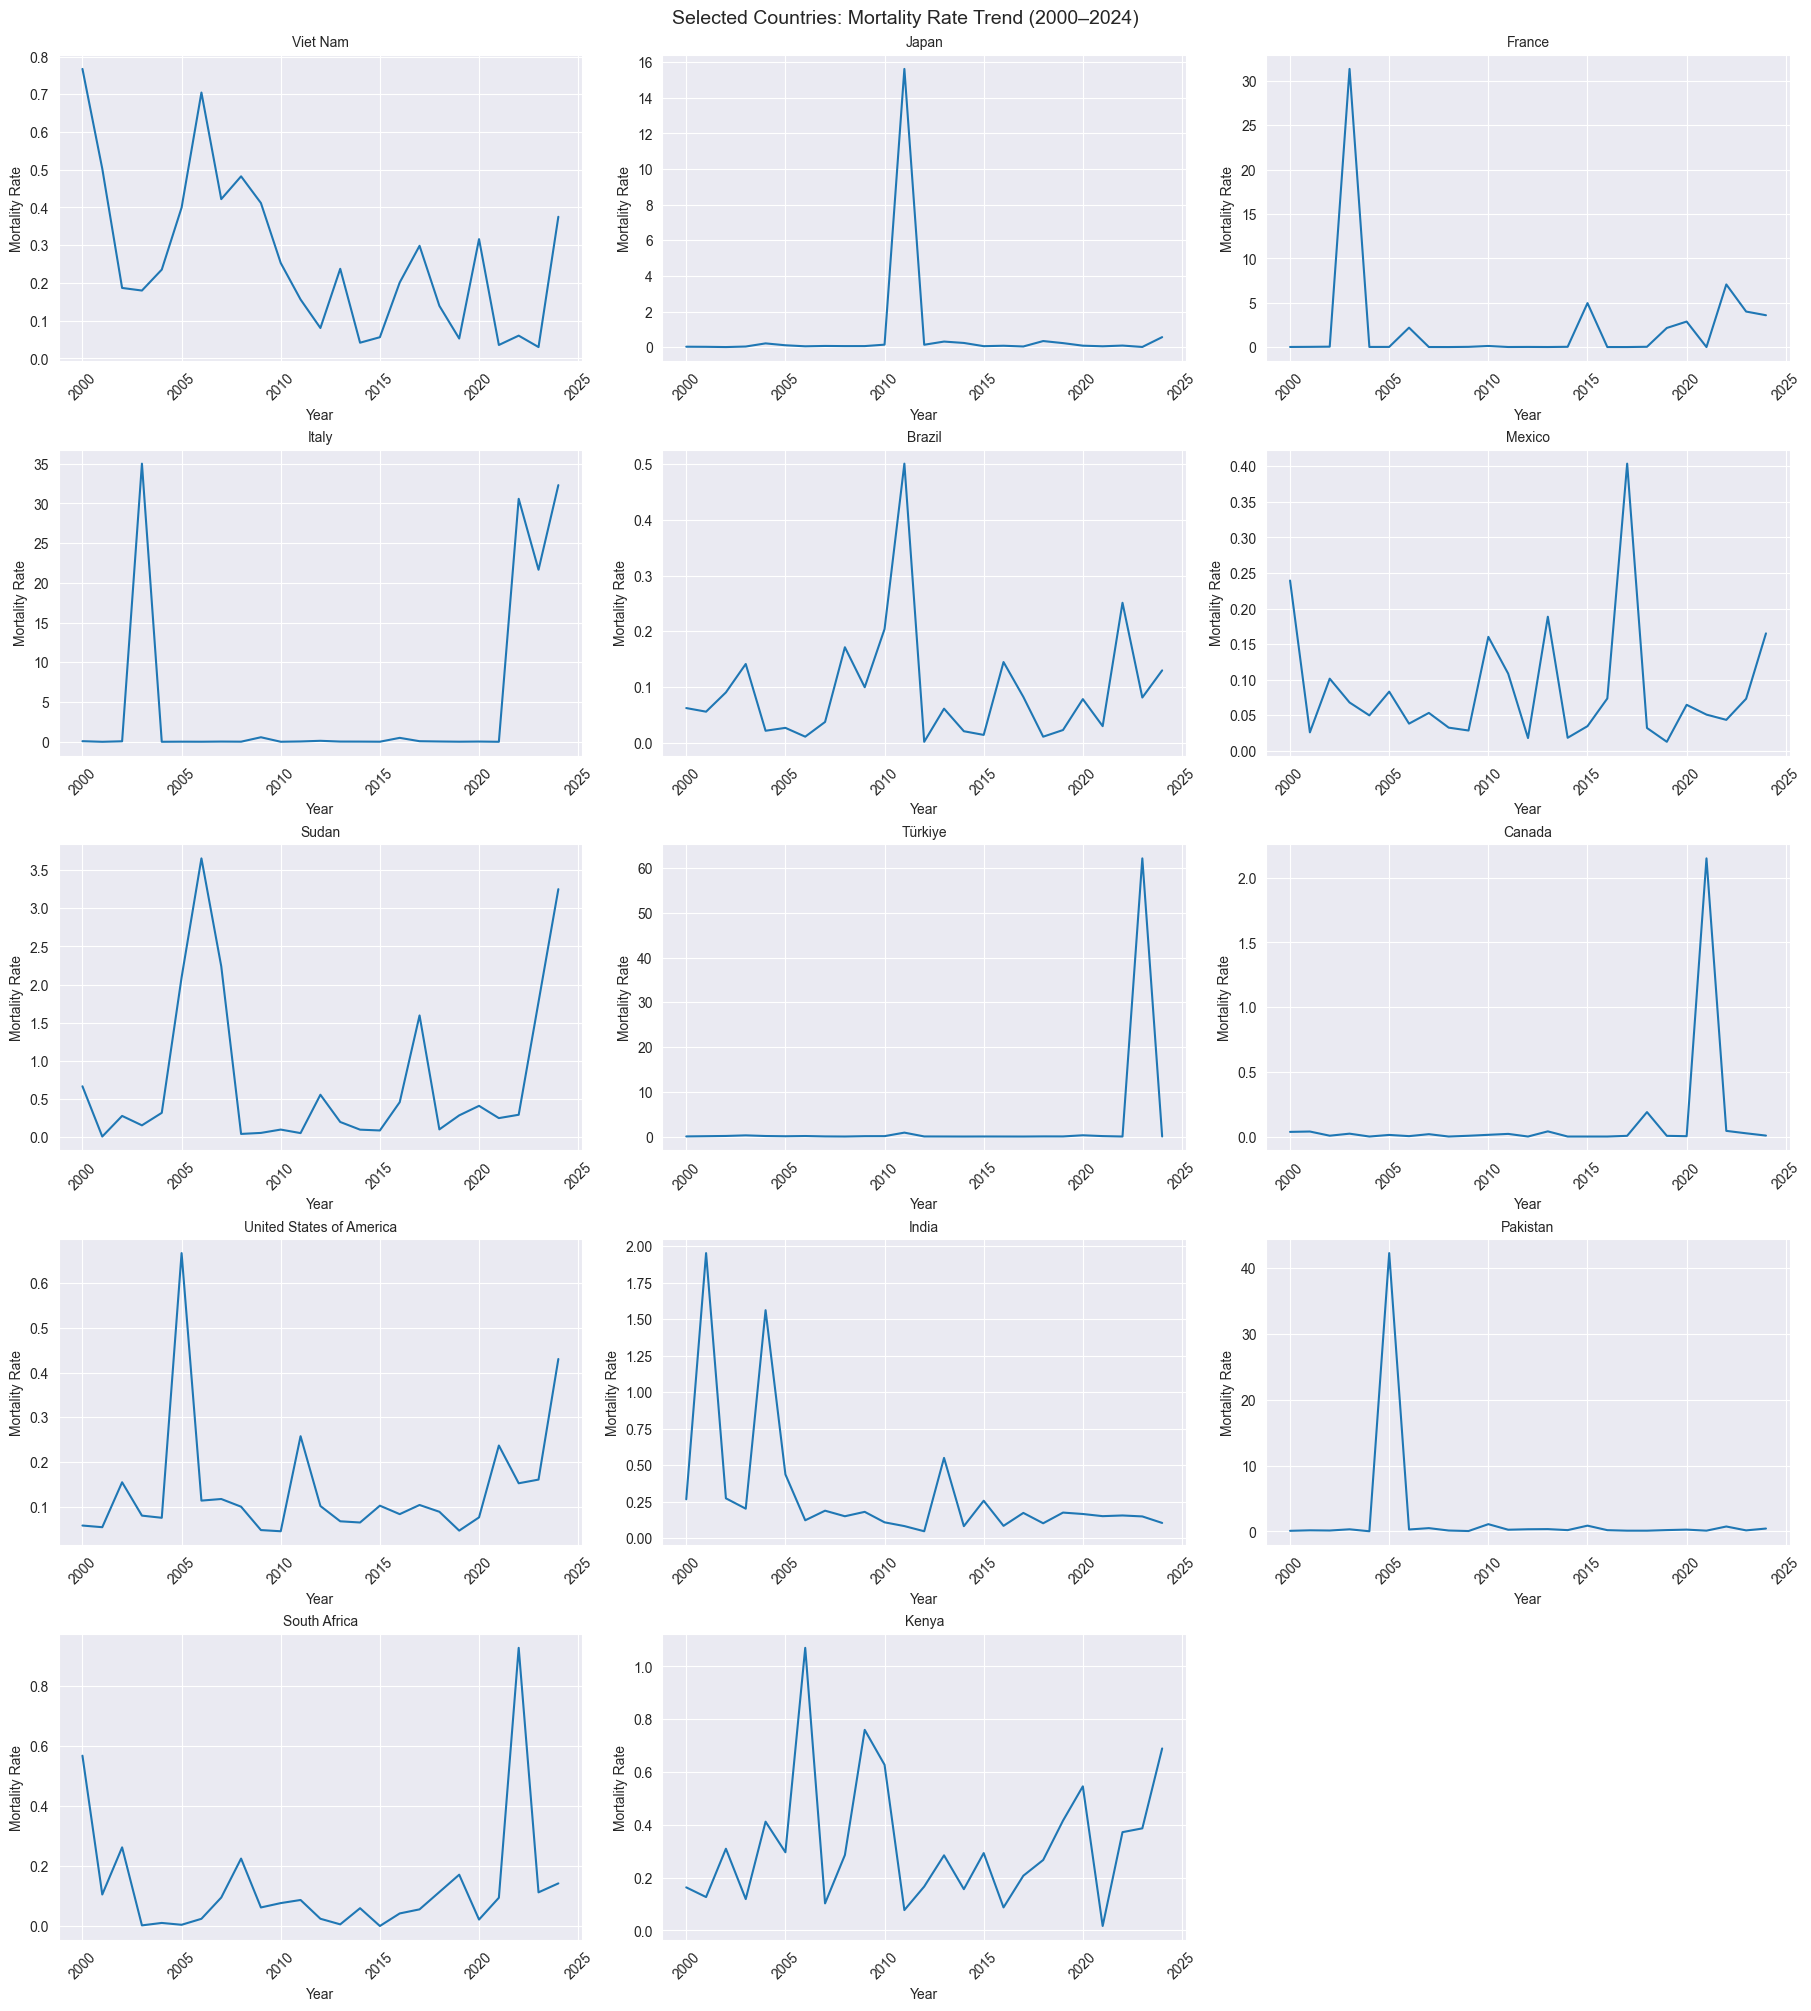

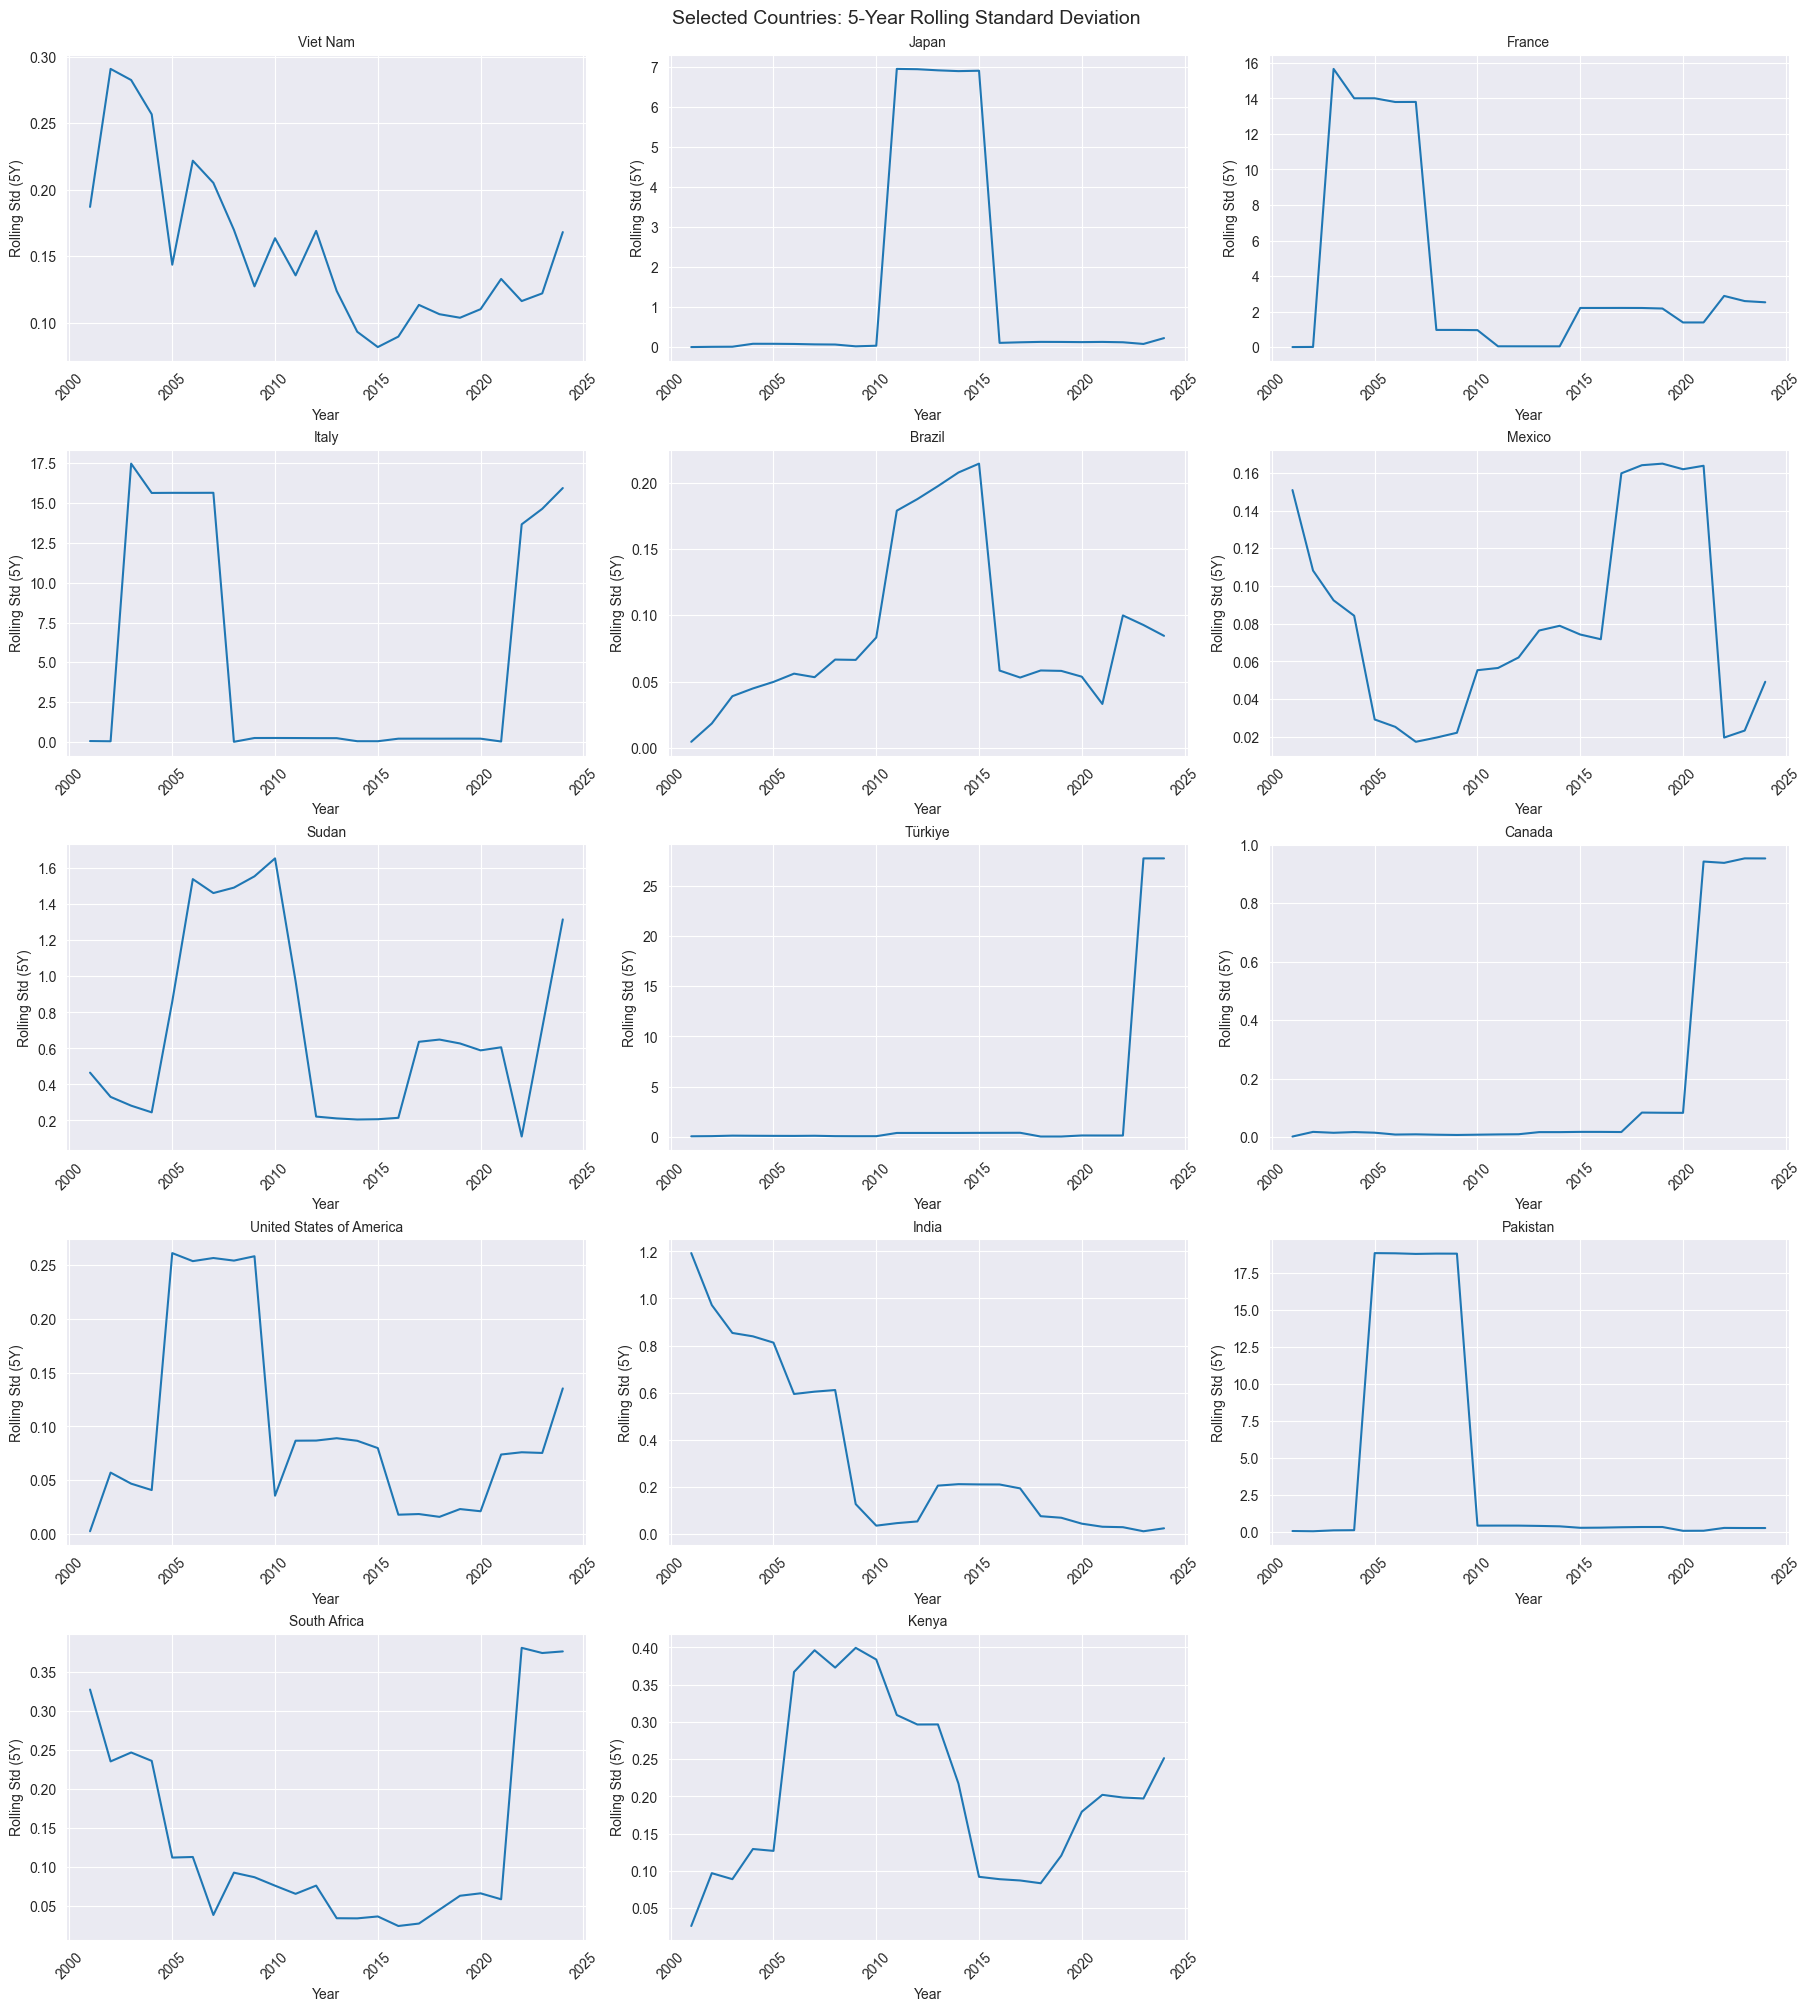

In [30]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 4.3.1 Define Selected Countries
selected_countries = [
    "Viet Nam", "Japan",
    "France", "Italy",
    "Brazil", "Mexico",
    "Sudan", "Türkiye",
    "Canada", "United States of America",
    "India", "Pakistan",
    "South Africa", "Kenya"
]

country_df = df[df["Country"].isin(selected_countries)].copy()

# 4.3.2 Country Trend Comparison (All Selected Countries)
country_trend = (
    country_df.groupby(["Country", "Year"])[["Total_Deaths", "Population"]]
    .sum()
    .reset_index()
    .sort_values(["Country", "Year"])
)

country_trend["Mortality_Rate"] = (
    country_trend["Total_Deaths"] / country_trend["Population"]
) * 100000

plt.figure(figsize=(16, 8), constrained_layout=True)
sns.lineplot(data=country_trend, x="Year", y="Mortality_Rate", hue="Country")
plt.title("Selected Countries - Mortality Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
plt.close()

# Prepare grouped series
plot_df = country_trend.copy()

countries = selected_countries
n = len(countries)

ncols = 3
nrows = int(np.ceil(n / ncols))
window = 5

# 4.3.3 Trend
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(18, 4.0 * nrows),
    sharex=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for i, c in enumerate(countries):
    ts = plot_df[plot_df["Country"] == c].sort_values("Year")
    ax = axes[i]
    ax.plot(ts["Year"], ts["Mortality_Rate"])
    ax.set_title(c, fontsize=10)
    ax.set_ylabel("Mortality Rate")
    ax.set_xlabel("Year")
    ax.tick_params(axis="x", labelbottom=True, labelrotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Selected Countries: Mortality Rate Trend (2000–2024)", fontsize=14)
plt.show()
plt.close()

# 4.3.4 Rolling Std (Volatility)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(18, 4.0 * nrows),
    sharex=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for i, c in enumerate(countries):
    ts = plot_df[plot_df["Country"] == c].sort_values("Year").copy()
    ts["Rolling_Std"] = ts["Mortality_Rate"].rolling(window=window, min_periods=1).std()

    ax = axes[i]
    ax.plot(ts["Year"], ts["Rolling_Std"])
    ax.set_title(c, fontsize=10)
    ax.set_ylabel(f"Rolling Std ({window}Y)")
    ax.set_xlabel("Year")
    ax.tick_params(axis="x", labelbottom=True, labelrotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Selected Countries: {window}-Year Rolling Standard Deviation", fontsize=14)
plt.show()
plt.close()